In [1]:
# ============================================================================
# TARGET & ROUTE DEPTH CLUSTERING - MAIN NOTEBOOK (FIXED)
# ============================================================================
# 
# FIXES APPLIED:
# 1. REMOVED duplicate re-fit that was overwriting cluster assignments
# 2. FIXED column count mismatch (was selecting 5, renaming to 4)
# 3. ADDED player name via JOIN
# 4. PRESERVED weighted clustering throughout
#
# WORKFLOW:
# 1. Run find_optimal_k.py first to determine k
# 2. Run this notebook to fit, name, validate, and upload
#
# ============================================================================

In [3]:
!conda install -c conda-forge awswrangler -y

Retrieving notices: done
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.0
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /home/ec2-user/anaconda3/envs/python3

  added / updated specs:
    - awswrangler


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    aws-c-auth-0.10.1          |       h2d2dd48_2         131 KB  conda-forge
    aws-c-event-stream-0.6.0   |       h9b893ba_1          58 KB  conda-forge
    aws-c-http-0.10.12         |       h4bacb7b_1         221 KB  conda-forge
    aws-c-io-0.26.3            |       hc87160b_0         177 KB  conda-forge
    aws-c-mqtt-0.15.2          |       he9ea9c5_1         217 KB  conda-forge
    aws-c-s3-0.11.5            |       h6d69fc9_5  

In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import boto3
from io import StringIO
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import awswrangler as wr

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
from cluster_naming import name_route_clusters, name_target_clusters

In [ ]:
def query_athena(query, database='nfl_data'):
    """Execute Athena query and return DataFrame"""
    df = wr.athena.read_sql_query(
        sql=query,
        database=database,
        ctas_approach=False
    )
    return df

In [ ]:
# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================

query_tgt_rte = """
SELECT  agg.*,
        CASE WHEN routes < 35 THEN 0 ELSE 1 END AS route_ind,
        CASE WHEN targets < 9 THEN 0 ELSE 1 END AS target_ind
FROM    nfl_data.vw_receiving_depth_weekly_agg agg
"""

print("Querying Athena...")
df_tgt_rte = query_athena(query_tgt_rte)
print(f"Loaded {len(df_tgt_rte):,} player-seasons")
print(f"Columns: {df_tgt_rte.columns.tolist()}")

In [12]:
df_tgt_rte

,player_id,team,season,routes,behind_los_routes,short_routes,medium_routes,deep_routes,targets,behind_los_targets,...,route_ind,target_ind,deep_rte_rate,medium_rte_rate,short_rte_rate,behind_los_rte_rate,deep_tgt_rate,medium_tgt_rate,short_tgt_rate,behind_los_tgt_rate
0,11028.0,TEN,2020.0,101.0,14.0,48.0,26.0,13.0,16.0,0.0,...,1,1,12.9,25.7,47.5,13.9,37.5,31.2,31.2,0.0
1,9443.0,ATL,2020.0,185.0,25.0,80.0,50.0,30.0,31.0,12.0,...,1,1,16.2,27.0,43.2,13.5,3.2,3.2,54.8,38.7
2,11062.0,CHI,2020.0,8.0,1.0,3.0,2.0,2.0,0.0,0.0,...,0,0,25.0,25.0,37.5,12.5,NaN,NaN,NaN,NaN
3,3625.0,CHI,2020.0,35.0,8.0,14.0,4.0,9.0,5.0,1.0,...,1,0,25.7,11.4,40.0,22.9,40.0,20.0,20.0,20.0
4,7971.0,NE,2020.0,104.0,29.0,40.0,28.0,7.0,30.0,18.0,...,1,1,6.7,26.9,38.5,27.9,3.3,10.0,26.7,60.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6251,8647.0,LA,2021.0,311.0,43.0,151.0,80.0,37.0,70.0,5.0,...,1,1,11.9,25.7,48.6,13.8,20.0,32.9,40.0,7.1
6252,46445.0,LAC,2021.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0,...,0,0,0.0,0.0,100.0,0.0,0.0,0.0,100.0,0.0
6253,47173.0,NO,2021.0,5.0,0.0,5.0,0.0,0.0,2.0,0.0,...,0,0,0.0,0.0,100.0,0.0,0.0,0.0,100.0,0.0
6254,47542.0,CAR,2021.0,7.0,2.0,3.0,2.0,0.0,2.0,0.0,...,0,0,0.0,28.6,42.9,28.6,0.0,0.0,100.0,0.0


In [13]:
# Route rates
df_tgt_rte['deep_rte_rate'] = (df_tgt_rte['deep_routes'] / df_tgt_rte['routes'] * 100).round(1)
df_tgt_rte['medium_rte_rate'] = (df_tgt_rte['medium_routes'] / df_tgt_rte['routes'] * 100).round(1)
df_tgt_rte['short_rte_rate'] = (df_tgt_rte['short_routes'] / df_tgt_rte['routes'] * 100).round(1)
df_tgt_rte['behind_los_rte_rate'] = (df_tgt_rte['behind_los_routes'] / df_tgt_rte['routes'] * 100).round(1)

features_rte = ['deep_rte_rate', 'medium_rte_rate', 'short_rte_rate', 'behind_los_rte_rate']

print("\nRoute Rate Summary:")
print(df_tgt_rte[features_rte].describe())


Route Rate Summary:
       deep_rte_rate  medium_rte_rate  short_rte_rate  behind_los_rte_rate
count    6011.000000      6011.000000     6011.000000          6011.000000
mean       12.216453        21.660090       48.177092            17.945849
std        13.315462        15.924456       19.607655            16.254668
min         0.000000         0.000000        0.000000             0.000000
25%         7.100000        16.100000       42.900000            11.000000
50%        11.100000        20.800000       49.500000            15.800000
75%        14.500000        25.300000       54.700000            21.000000
max       100.000000       100.000000      100.000000           100.000000


In [14]:
# Target rates
df_tgt_rte['deep_tgt_rate'] = (df_tgt_rte['deep_targets'] / df_tgt_rte['targets'] * 100).round(1)
df_tgt_rte['medium_tgt_rate'] = (df_tgt_rte['medium_targets'] / df_tgt_rte['targets'] * 100).round(1)
df_tgt_rte['short_tgt_rate'] = (df_tgt_rte['short_targets'] / df_tgt_rte['targets'] * 100).round(1)
df_tgt_rte['behind_los_tgt_rate'] = (df_tgt_rte['behind_los_targets'] / df_tgt_rte['targets'] * 100).round(1)

features_tgt = ['deep_tgt_rate', 'medium_tgt_rate', 'short_tgt_rate', 'behind_los_tgt_rate']

print("\nTarget Rate Summary:")
print(df_tgt_rte[features_tgt].describe())


Target Rate Summary:
       deep_tgt_rate  medium_tgt_rate  short_tgt_rate  behind_los_tgt_rate
count    5190.000000      5190.000000     5190.000000          5190.000000
mean       10.551638        17.889904       51.012100            20.546782
std        15.069340        19.182888       24.996492            25.361754
min         0.000000         0.000000        0.000000             0.000000
25%         0.000000         0.000000       37.500000             0.000000
50%         5.300000        15.700000       50.000000            10.000000
75%        16.700000        29.500000       65.075000            33.300000
max       100.000000       100.000000      100.000000           100.000000


In [15]:
# ============================================================================
# STEP 3: FILTER
# ============================================================================

df_rte_filtered = df_tgt_rte[df_tgt_rte['route_ind'] == 1].copy()
df_tgt_filtered = df_tgt_rte[df_tgt_rte['target_ind'] == 1].copy()

print(f"\nFiltered to {len(df_rte_filtered):,} player-seasons for routes (route_ind = 1)")
print(f"Filtered to {len(df_tgt_filtered):,} player-seasons for targets (target_ind = 1)")


Filtered to 3,800 player-seasons for routes (route_ind = 1)
Filtered to 3,430 player-seasons for targets (target_ind = 1)


In [16]:
# ============================================================================
# STEP 4: PREPARE CLUSTERING DATA WITH WEIGHTS
# ============================================================================

X_rte_values = df_rte_filtered[features_rte].values
weights_route = np.sqrt(df_rte_filtered['routes'].values)

X_tgt_values = df_tgt_filtered[features_tgt].values
weights_target = np.sqrt(df_tgt_filtered['targets'].values)

print(f"\nRoute clustering: {len(X_rte_values):,} samples, weights {weights_route.min():.1f} to {weights_route.max():.1f}")
print(f"Target clustering: {len(X_tgt_values):,} samples, weights {weights_target.min():.1f} to {weights_target.max():.1f}")


Route clustering: 3,800 samples, weights 5.9 to 26.4
Target clustering: 3,430 samples, weights 3.0 to 15.2



ROUTE CLUSTERING k=6 - FIT ONCE


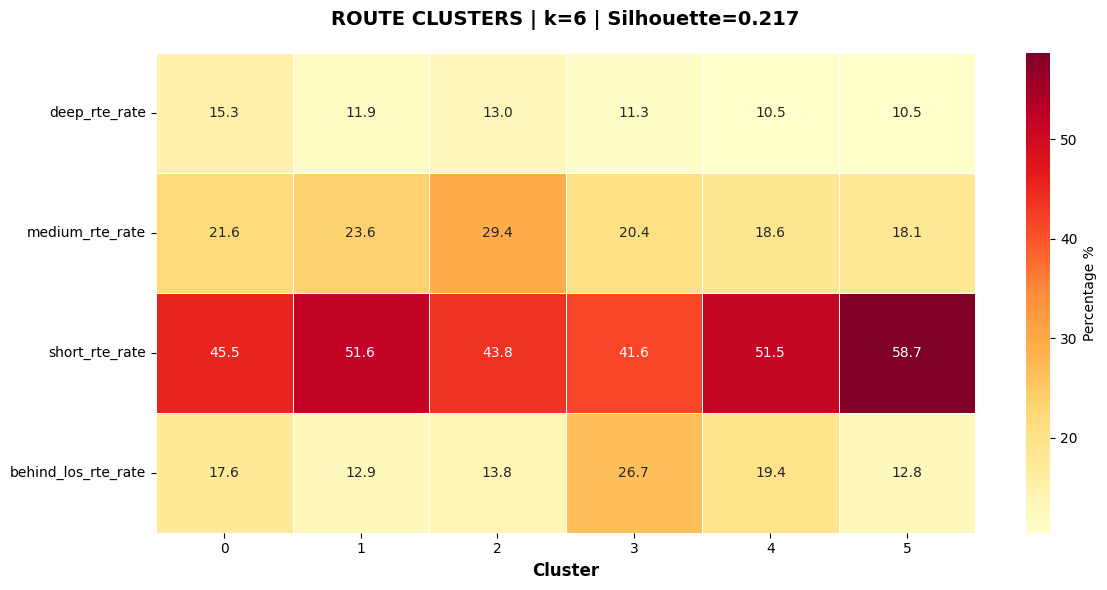


ROUTE CENTROIDS - USE THESE TO NAME:
 cluster  count  deep_rte_rate  medium_rte_rate  short_rte_rate  behind_los_rte_rate
       0    662      15.326417        21.596315       45.491752            17.586260
       1    839      11.860561        23.630253       51.621029            12.890540
       2    526      12.993989        29.419927       43.790622            13.796171
       3    391      11.281773        20.390631       41.577208            26.747672
       4    810      10.533046        18.637299       51.471294            19.359058
       5    572      10.450143        18.050410       58.688340            12.810308

ROUTE CLUSTERING k=6 - SAMPLE PLAYERS PER CLUSTER

CLUSTER 0 (n=662)
 player_id team  season  routes  deep_rte_rate  medium_rte_rate  short_rte_rate  behind_los_rte_rate
    8642.0   TB  2021.0   650.0           11.7             24.5            45.4                 18.5
    8642.0   TB  2020.0   633.0           16.6             22.4            47.4                

In [17]:
# ============================================================================
# STEP 5: FIT ROUTE CLUSTERS (k=6) - FIT ONCE, USE EVERYWHERE
# ============================================================================

print("\n" + "="*80)
print("ROUTE CLUSTERING k=6 - FIT ONCE")
print("="*80)

kmeans_rte = KMeans(n_clusters=6, n_init=25, random_state=42)
kmeans_rte.fit(X_rte_values, sample_weight=weights_route)
df_rte_filtered['cluster'] = kmeans_rte.labels_

# Calculate silhouette
sil_score_rte = silhouette_score(X_rte_values, kmeans_rte.labels_)

# Create centroids dataframe for heatmap
centroids_rte_display = pd.DataFrame(kmeans_rte.cluster_centers_, columns=features_rte)
centroids_rte_display['cluster'] = range(6)
centroids_rte_display['count'] = pd.Series(kmeans_rte.labels_).value_counts().sort_index().values
centroids_rte_display = centroids_rte_display[['cluster', 'count'] + features_rte]

# Heatmap visualization
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    centroids_rte_display[features_rte].T,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Percentage %'},
    xticklabels=centroids_rte_display['cluster'],
    yticklabels=features_rte,
    ax=ax,
    linewidths=0.5
)
ax.set_title(f'ROUTE CLUSTERS | k=6 | Silhouette={sil_score_rte:.3f}', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print centroids table
print("\nROUTE CENTROIDS - USE THESE TO NAME:")
print(centroids_rte_display.to_string(index=False))

# Show sample players
print("\n" + "="*80)
print("ROUTE CLUSTERING k=6 - SAMPLE PLAYERS PER CLUSTER")
print("="*80)

for cluster in range(8):
    cluster_players = df_rte_filtered[df_rte_filtered['cluster'] == cluster].copy()
    top_3 = cluster_players.nlargest(3, 'routes')[
        ['player_id', 'team', 'season', 'routes',
         'deep_rte_rate', 'medium_rte_rate', 'short_rte_rate', 'behind_los_rte_rate']
    ]
    print(f"\nCLUSTER {cluster} (n={len(cluster_players)})")
    print(top_3.to_string(index=False))

In [12]:
# RT 6: ['DT', 'SMT', 'MT', 'BT', 'RB', 'ST']
# RT 6: ['', '', '', '', '', '']


TARGET CLUSTERING k=8 - FIT ONCE


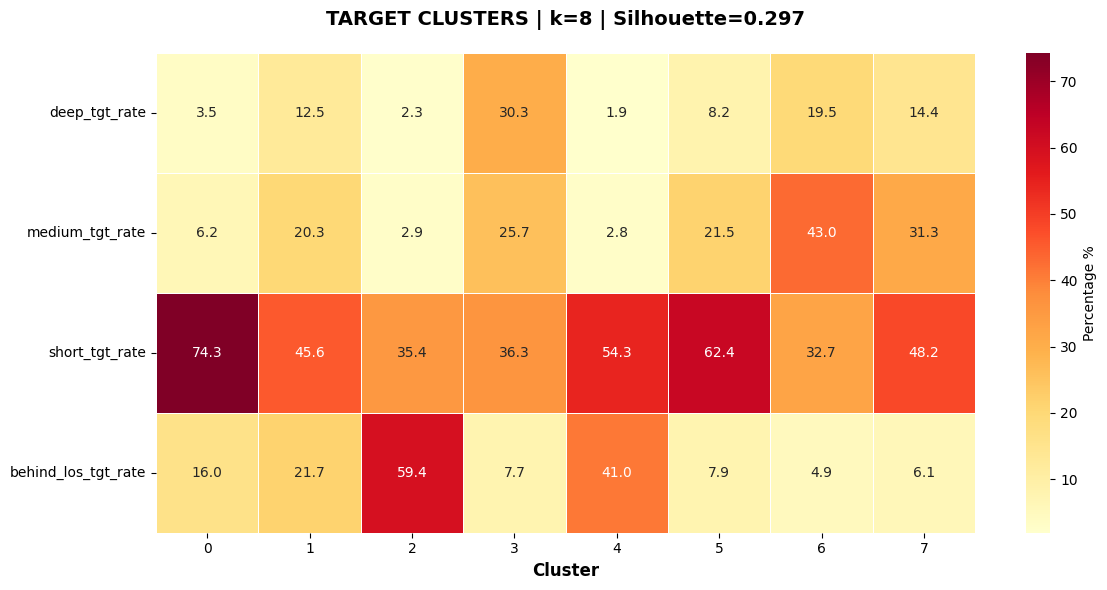


TARGET CENTROIDS - USE THESE TO NAME:
 cluster  count  deep_tgt_rate  medium_tgt_rate  short_tgt_rate  behind_los_tgt_rate
       0    367       3.506623         6.183269       74.288036            16.028440
       1    318      12.469371        20.290246       45.558874            21.680878
       2    313       2.329302         2.869010       35.357102            59.444730
       3    361      30.337026        25.686400       36.307410             7.673063
       4    479       1.940179         2.815495       54.296989            40.951563
       5    604       8.210560        21.491597       62.443545             7.853014
       6    358      19.490610        42.959437       32.685238             4.865627
       7    630      14.419697        31.327594       48.168070             6.083118

TARGET CLUSTERING k=8 - SAMPLE PLAYERS PER CLUSTER

CLUSTER 0 (n=367)
 player_id team  season  targets  deep_tgt_rate  medium_tgt_rate  short_tgt_rate  behind_los_tgt_rate
   11778.0  JAX  2023.0

In [18]:
# ============================================================================
# STEP 6: FIT TARGET CLUSTERS (k=8) - FIT ONCE, USE EVERYWHERE
# ============================================================================

print("\n" + "="*80)
print("TARGET CLUSTERING k=8 - FIT ONCE")
print("="*80)

kmeans_tgt = KMeans(n_clusters=8, n_init=25, random_state=42)
kmeans_tgt.fit(X_tgt_values, sample_weight=weights_target)
df_tgt_filtered['cluster'] = kmeans_tgt.labels_

# Calculate silhouette
sil_score_tgt = silhouette_score(X_tgt_values, kmeans_tgt.labels_)

# Create centroids dataframe for heatmap
centroids_tgt_display = pd.DataFrame(kmeans_tgt.cluster_centers_, columns=features_tgt)
centroids_tgt_display['cluster'] = range(8)
centroids_tgt_display['count'] = pd.Series(kmeans_tgt.labels_).value_counts().sort_index().values
centroids_tgt_display = centroids_tgt_display[['cluster', 'count'] + features_tgt]

# Heatmap visualization
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    centroids_tgt_display[features_tgt].T,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Percentage %'},
    xticklabels=centroids_tgt_display['cluster'],
    yticklabels=features_tgt,
    ax=ax,
    linewidths=0.5
)
ax.set_title(f'TARGET CLUSTERS | k=8 | Silhouette={sil_score_tgt:.3f}', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print centroids table
print("\nTARGET CENTROIDS - USE THESE TO NAME:")
print(centroids_tgt_display.to_string(index=False))

# Show sample players
print("\n" + "="*80)
print("TARGET CLUSTERING k=8 - SAMPLE PLAYERS PER CLUSTER")
print("="*80)

for cluster in range(8):
    cluster_players = df_tgt_filtered[df_tgt_filtered['cluster'] == cluster].copy()
    top_3 = cluster_players.nlargest(3, 'targets')[
        ['player_id', 'team', 'season', 'targets',
         'deep_tgt_rate', 'medium_tgt_rate', 'short_tgt_rate', 'behind_los_tgt_rate']
    ]
    print(f"\nCLUSTER {cluster} (n={len(cluster_players)})")
    print(top_3.to_string(index=False))

In [16]:
# TGT 8: ['ST', 'G', 'BT', 'DT', 'RB', 'SMT', 'MT', 'ML']
# TGT 8: ['', '', '', '', '', '', '', '']

In [ ]:
# ============================================================================
# ROUTE CLUSTER NAMING (AUTO)
# ============================================================================

route_cluster_names = name_route_clusters(centroids_rte_display)

print("Route cluster auto-names:")
for cluster, name in sorted(route_cluster_names.items()):
    print(f"  Cluster {cluster} → {name}")

In [ ]:
# ============================================================================
# TARGET CLUSTER NAMING (AUTO)
# ============================================================================

target_cluster_names = name_target_clusters(centroids_tgt_display)

print("Target cluster auto-names:")
for cluster, name in sorted(target_cluster_names.items()):
    print(f"  Cluster {cluster} → {name}")

In [22]:
# ============================================================================
# STEP 8: CREATE OUTPUTS - NO RE-FIT, JUST USE EXISTING CLUSTERS
# ============================================================================

# ROUTE OUTPUT - use clusters already assigned, correct column count
output_rte = df_rte_filtered[['player_id', 'team', 'season', 'cluster']].copy()
output_rte.columns = ['player_id', 'team', 'season', 'rte_cluster']  # 4 columns = 4 names
output_rte['rte_cluster_name'] = output_rte['rte_cluster'].map(route_cluster_names)

print("\n" + "="*80)
print("ROUTE CLUSTER OUTPUT")
print("="*80)
print(f"Total records: {len(output_rte):,}")
print(f"Columns: {output_rte.columns.tolist()}")
print("\nCluster distribution:")
print(output_rte['rte_cluster_name'].value_counts())
print("\nSample:")
print(output_rte.head(10).to_string(index=False))


ROUTE CLUSTER OUTPUT
Total records: 3,800
Columns: ['player_id', 'team', 'season', 'rte_cluster', 'rte_cluster_name']

Cluster distribution:
rte_cluster_name
SMT    839
RB     810
DT     662
ST     572
MT     526
BT     391
Name: count, dtype: int64

Sample:
 player_id team  season  rte_cluster rte_cluster_name
   11028.0  TEN  2020.0            1              SMT
    9443.0  ATL  2020.0            2               MT
    3625.0  CHI  2020.0            0               DT
    7971.0   NE  2020.0            3               BT
    5612.0  BUF  2020.0            2               MT
   26408.0  NYJ  2020.0            5               ST
   13750.0  LAC  2020.0            3               BT
   12088.0  NYG  2020.0            1              SMT
    3623.0  DET  2020.0            0               DT
    6597.0  WAS  2020.0            4               RB


In [23]:
# TARGET OUTPUT - use clusters already assigned
output_tgt = df_tgt_filtered[['player_id', 'team', 'season', 'cluster']].copy()
output_tgt.columns = ['player_id', 'team', 'season', 'tgt_cluster']  # 4 columns = 4 names
output_tgt['tgt_cluster_name'] = output_tgt['tgt_cluster'].map(target_cluster_names)

print("\n" + "="*80)
print("TARGET CLUSTER OUTPUT")
print("="*80)
print(f"Total records: {len(output_tgt):,}")
print(f"Columns: {output_tgt.columns.tolist()}")
print("\nCluster distribution:")
print(output_tgt['tgt_cluster_name'].value_counts())
print("\nSample:")
print(output_tgt.head(10).to_string(index=False))


TARGET CLUSTER OUTPUT
Total records: 3,430
Columns: ['player_id', 'team', 'season', 'tgt_cluster', 'tgt_cluster_name']

Cluster distribution:
tgt_cluster_name
ML     630
SMT    604
RB     479
ST     367
DT     361
MT     358
G      318
BT     313
Name: count, dtype: int64

Sample:
 player_id team  season  tgt_cluster tgt_cluster_name
   11028.0  TEN  2020.0            3               DT
    9443.0  ATL  2020.0            4               RB
    7971.0   NE  2020.0            2               BT
   26408.0  NYJ  2020.0            4               RB
   13750.0  LAC  2020.0            4               RB
   12088.0  NYG  2020.0            7               ML
    3623.0  DET  2020.0            4               RB
    6597.0  WAS  2020.0            7               ML
   11932.0   SF  2020.0            0               ST
   26618.0  IND  2020.0            2               BT


In [24]:
# ============================================================================
# STEP 9: VALIDATION - VERIFY NAMES MATCH CENTROIDS
# ============================================================================

print("\n" + "="*80)
print("ROUTE CLUSTER VALIDATION - VERIFY NAMES")
print("="*80)

for cluster in range(6):
    cluster_players = df_rte_filtered[df_rte_filtered['cluster'] == cluster].copy()
    sample = cluster_players.sample(min(5, len(cluster_players)))[
        ['player_id', 'team', 'season', 'routes',
         'behind_los_rte_rate', 'short_rte_rate', 'medium_rte_rate', 'deep_rte_rate']
    ]
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster} - Name: '{route_cluster_names.get(cluster, 'UNNAMED')}'")
    print(f"Total in cluster: {len(cluster_players)}")
    print(f"{'='*80}")
    print(sample.to_string(index=False))
    print(f"\nCENTROID: Deep={cluster_players['deep_rte_rate'].mean():.1f}% | Med={cluster_players['medium_rte_rate'].mean():.1f}% | Short={cluster_players['short_rte_rate'].mean():.1f}% | Behind={cluster_players['behind_los_rte_rate'].mean():.1f}%")


ROUTE CLUSTER VALIDATION - VERIFY NAMES

CLUSTER 0 - Name: 'DT'
Total in cluster: 662
 player_id team  season  routes  behind_los_rte_rate  short_rte_rate  medium_rte_rate  deep_rte_rate
    6671.0  PHI  2018.0    68.0                 20.6            47.1             19.1           13.2
    5718.0  PIT  2018.0   599.0                 17.5            48.1             20.7           13.7
    9185.0  CHI  2018.0   416.0                 18.3            47.6             20.0           14.2
   84329.0   GB  2024.0   319.0                 21.3            43.6             16.6           18.5
    9447.0  MIA  2019.0   510.0                 13.3            46.7             24.9           15.1

CENTROID: Deep=15.8% | Med=21.4% | Short=45.3% | Behind=17.6%

CLUSTER 1 - Name: 'SMT'
Total in cluster: 839
 player_id team  season  routes  behind_los_rte_rate  short_rte_rate  medium_rte_rate  deep_rte_rate
   57337.0  ARZ  2025.0   190.0                 12.6            52.1             23.2           

In [25]:
print("\n" + "="*80)
print("TARGET CLUSTER VALIDATION - VERIFY NAMES")
print("="*80)

for cluster in range(8):
    cluster_players = df_tgt_filtered[df_tgt_filtered['cluster'] == cluster].copy()
    sample = cluster_players.sample(min(5, len(cluster_players)))[
        ['player_id', 'team', 'season', 'targets',
         'behind_los_tgt_rate', 'short_tgt_rate', 'medium_tgt_rate', 'deep_tgt_rate']
    ]
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster} - Name: '{target_cluster_names.get(cluster, 'UNNAMED')}'")
    print(f"Total in cluster: {len(cluster_players)}")
    print(f"{'='*80}")
    print(sample.to_string(index=False))
    print(f"\nCENTROID: Deep={cluster_players['deep_tgt_rate'].mean():.1f}% | Med={cluster_players['medium_tgt_rate'].mean():.1f}% | Short={cluster_players['short_tgt_rate'].mean():.1f}% | Behind={cluster_players['behind_los_tgt_rate'].mean():.1f}%")



TARGET CLUSTER VALIDATION - VERIFY NAMES

CLUSTER 0 - Name: 'ST'
Total in cluster: 367
 player_id team  season  targets  behind_los_tgt_rate  short_tgt_rate  medium_tgt_rate  deep_tgt_rate
  124173.0   GB  2024.0     15.0                  0.0            86.7              6.7            6.7
    7940.0  SEA  2016.0     21.0                 14.3            66.7              9.5            9.5
   47050.0  HST  2018.0     27.0                  7.4            70.4             11.1           11.1
   60917.0  BLT  2024.0     11.0                  9.1            72.7              9.1            9.1
   45817.0  MIN  2020.0     15.0                 26.7            66.7              0.0            6.7

CENTROID: Deep=3.5% | Med=5.9% | Short=75.0% | Behind=15.6%

CLUSTER 1 - Name: 'G'
Total in cluster: 318
 player_id team  season  targets  behind_los_tgt_rate  short_tgt_rate  medium_tgt_rate  deep_tgt_rate
  122518.0  HST  2023.0     22.0                 18.2            45.5             13.6      

In [26]:
# ============================================================================
# STEP 10: UPLOAD TO S3
# ============================================================================
s3_client = boto3.client('s3')

# Route centroids
centroids_rte_display['name'] = centroids_rte_display['cluster'].map(route_cluster_names)
centroids_buffer_rte = StringIO()
centroids_rte_display[['cluster', 'name', 'count'] + features_rte].to_csv(centroids_buffer_rte, index=False)
s3_client.put_object(
    Bucket='nfl-pff-data-lucas',
    Key='clustering/centroids/rte_cluster/rte_centroids_2025.csv',
    Body=centroids_buffer_rte.getvalue()
)
print("✓ Saved centroids to s3://nfl-pff-data-lucas/clustering/centroids/rte_cluster/rte_centroids_2025.csv")

# Target centroids
centroids_tgt_display['name'] = centroids_tgt_display['cluster'].map(target_cluster_names)
centroids_buffer_tgt = StringIO()
centroids_tgt_display[['cluster', 'name', 'count'] + features_tgt].to_csv(centroids_buffer_tgt, index=False)
s3_client.put_object(
    Bucket='nfl-pff-data-lucas',
    Key='clustering/centroids/tgt_cluster/tgt_centroids_2025.csv',
    Body=centroids_buffer_tgt.getvalue()
)
print("✓ Saved centroids to s3://nfl-pff-data-lucas/clustering/centroids/tgt_cluster/tgt_centroids_2025.csv")

✓ Saved centroids to s3://nfl-pff-data-lucas/clustering/centroids/rte_cluster/rte_centroids_2025.csv
✓ Saved centroids to s3://nfl-pff-data-lucas/clustering/centroids/tgt_cluster/tgt_centroids_2025.csv


In [27]:
# ============================================================================
# STEP 10: UPLOAD TO S3
# ============================================================================

s3_client = boto3.client('s3')

# Route clusters
csv_buffer_rte = StringIO()
output_rte.to_csv(csv_buffer_rte, index=False)
s3_client.put_object(
    Bucket='nfl-pff-data-lucas',
    Key='clustering/player_clusters/rte_cluster/receiving_rte_cluster_2025.csv',
    Body=csv_buffer_rte.getvalue()
)
print("\n✓ Saved routes to s3://nfl-pff-data-lucas/clustering/player_clusters/rte_cluster/receiving_rte_cluster_2025.csv")



✓ Saved routes to s3://nfl-pff-data-lucas/clustering/player_clusters/rte_cluster/receiving_rte_cluster_2025.csv


In [28]:
# Target clusters
csv_buffer_tgt = StringIO()
output_tgt.to_csv(csv_buffer_tgt, index=False)
s3_client.put_object(
    Bucket='nfl-pff-data-lucas',
    Key='clustering/player_clusters/tgt_cluster/receiving_tgt_cluster_2025.csv',
    Body=csv_buffer_tgt.getvalue()
)
print("✓ Saved targets to s3://nfl-pff-data-lucas/clustering/player_clusters/tgt_cluster/receiving_tgt_cluster_2025.csv")


✓ Saved targets to s3://nfl-pff-data-lucas/clustering/player_clusters/tgt_cluster/receiving_tgt_cluster_2025.csv
